In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
import matplotlib.ticker as mticker
import warnings

In [2]:
result = pd.read_csv('metrics_results/mar1_analysis.csv', low_memory=False)
perf   = pd.read_csv('metrics_results/performance_results.csv')

In [3]:
# Clean observation subset — mirrors the filter inside analyze_route_performance
clean = result[
    result['match_type'].isin(['stst', 'fallback_pid', 'fallback_route']) &
    ~result['pre_trip'].fillna(False) &
    ~result['is_ghost'].fillna(False) &
    result['delay_minutes'].notna()
].copy()

In [4]:
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':        'monospace',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.color':         '#2a2a3a',
    'grid.linewidth':     0.5,
    'axes.facecolor':     '#0f0f1a',
    'figure.facecolor':   '#0f0f1a',
    'text.color':         '#ffffff',
    'axes.labelcolor':    '#e0e0f0',
    'xtick.color':        '#FFFFFF',
    'ytick.color':        '#FFFFFF',
    'axes.titlecolor':    '#ffffff',
    'axes.titlesize':     13,
    'axes.labelsize':     10,
})

BG     = '#0f0f1a'
PANEL  = '#16162a'
GREEN  = '#03ffb3'
YELLOW = '#ffbb00'
ORANGE = '#ff5100'
RED    = '#ff0033'
BLUE   = '#005eff'
GREY   = '#555577'
WHITE  = '#e0e0f0'

TOD_ORDER = ['Early Morning', 'AM Peak', 'Midday', 'PM Peak', 'Evening']
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

def otp_color(v):
    if v >= 85: return GREEN
    if v >= 75: return YELLOW
    if v >= 65: return ORANGE
    return RED

def delay_color(d):
    if d < -1:  return GREEN
    if d <= 3:  return YELLOW
    if d <= 8:  return ORANGE
    return RED

print('\u2713 Setup complete')

✓ Setup complete


In [5]:
# =============================================================================
# TRIP-LEVEL VIEW  (for plotting only)
# Metrics come from performance_results.csv which is already trip-aggregated.
# This just gives us a trip-level dataframe for hourly / TOD charts.
# =============================================================================

def get_tod(h):
    if h < 6:   return 'Early Morning'
    if h < 10:  return 'AM Peak'
    if h < 15:  return 'Midday'
    if h < 19:  return 'PM Peak'
    return 'Evening'

clean['tmstmp_dt']      = pd.to_datetime(clean['tmstmp'])
clean['hour']           = clean['tmstmp_dt'].dt.hour
clean['dow']            = clean['tmstmp_dt'].dt.day_name()
clean['is_weekend']     = clean['tmstmp_dt'].dt.dayofweek >= 5
clean['date']           = clean['tmstmp_dt'].dt.date
clean['sched_dep_hour'] = (clean['scheduled_departure_stop1'] // 60).astype('Int64')
clean['tod']            = clean['sched_dep_hour'].apply(
    lambda h: get_tod(h) if pd.notna(h) else get_tod(0)
)

trips = (
    clean.groupby(
        ['matched_trip_id', 'route_id', 'trip_date', 'date',
         'tod', 'dow', 'is_weekend'],
        observed=True
    )
    .agg(
        delay_median  = ('delay_minutes', 'median'),
        delay_max     = ('delay_minutes', 'max'),
        delay_p90     = ('delay_minutes', lambda x: x.quantile(0.9)),
        delay_std     = ('delay_minutes', 'std'),
        n_obs         = ('delay_minutes', 'count'),
        sched_dep_min = ('scheduled_departure_stop1', 'first'),
    )
    .reset_index()
)

trips['is_late']      = trips['delay_median'] > 3
trips['is_very_late'] = trips['delay_median'] > 15
trips['is_early']     = trips['delay_median'] < -1
trips['is_ontime']    = ~trips['is_early'] & ~trips['is_late']
trips['hour']         = (trips['sched_dep_min'] // 60).astype('Int64')

print(f'Trips: {len(trips):,} | Routes: {trips["route_id"].nunique()} | Dates: {trips["date"].nunique()}')

Trips: 224,251 | Routes: 123 | Dates: 15


In [6]:
# =============================================================================
# BUS TRUST SCORE  — built from performance_results.csv
# analyze_route_performance now computes all pillars at trip level,
# so we load directly without recomputing here.
# =============================================================================

df = perf.copy()
df['route_id'] = df['route_id'].astype(str)

# Route 169 UPS contamination correction
df.loc[df['route_id'] == '169', 'overall_otp_pct']     = 64.0
df.loc[df['route_id'] == '169', 'overall_delay_median'] = 1.9
df['is_corrected'] = df['route_id'] == '169'

# Pillars — directly from trip-aggregated perf columns
df['p_otp']         = df['overall_otp_pct'].clip(0, 100)
df['p_severity']    = (1 - (df['overall_delay_median'].clip(0, 15) / 15)) * 100
df['p_reliability'] = (1 - (df['overall_delay_std'].clip(0, 12) / 12)) * 100
df['p_ghost']       = (1 - (df['ghost_rate_pct'].clip(0, 40) / 40)) * 100

df['bus_trust_score'] = (
    0.45 * df['p_otp'] +
    0.25 * df['p_severity'] +
    0.20 * df['p_reliability'] +
    0.10 * df['p_ghost']
).round(1)

def trust_tier(s):
    if s >= 80: return 'HIGH'
    if s >= 65: return 'MODERATE'
    if s >= 50: return 'LOW'
    return 'CRITICAL'

df['trust_tier'] = df['bus_trust_score'].apply(trust_tier)
df_sorted        = df.sort_values('bus_trust_score', ascending=False).reset_index(drop=True)
df_sorted['rank'] = df_sorted.index + 1

WORST3 = df_sorted.tail(3)['route_id'].tolist()[::-1]
print('Worst 3 routes:', WORST3)
print(df_sorted.tail(3)[['route_id', 'bus_trust_score', 'trust_tier',
                           'overall_otp_pct', 'overall_delay_std', 'ghost_rate_pct']])

Worst 3 routes: ['62', '171', 'N5']
    route_id  bus_trust_score trust_tier  overall_otp_pct  overall_delay_std  \
120       N5             61.7        LOW            77.31              10.36   
121      171             57.7        LOW            61.66              11.03   
122       62             56.4        LOW            50.64               6.26   

     ghost_rate_pct  
120           64.48  
121           16.55  
122           23.96  


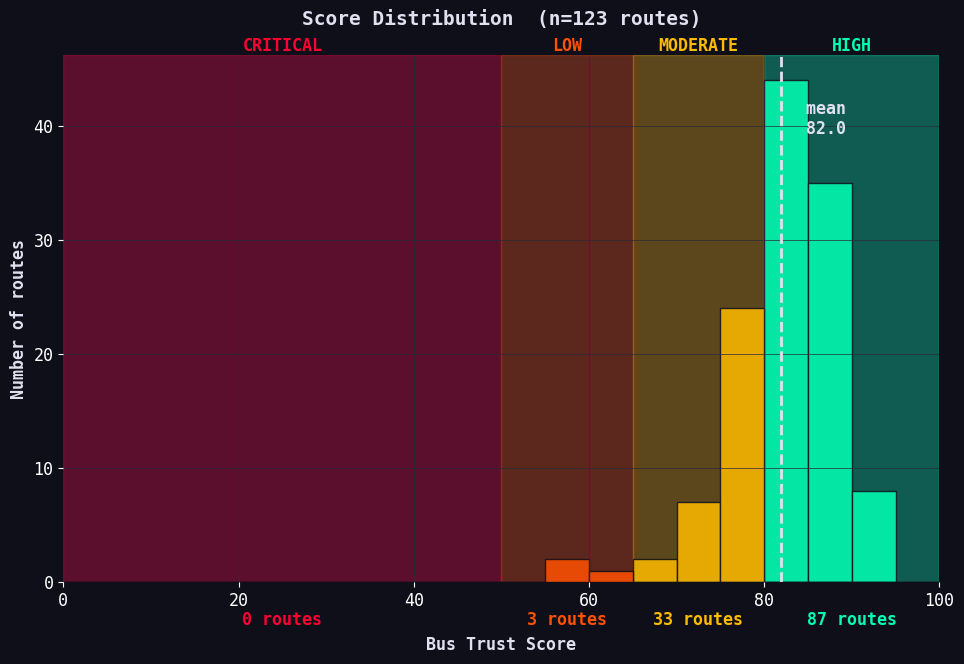

✓ Figure 1 saved


In [7]:
# =============================================================================
# FIGURE 1 — Distribution of Bus Trust Scores
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)

scores     = df_sorted['bus_trust_score']
tier_bands = [(80,100,GREEN,'HIGH'),(65,80,YELLOW,'MODERATE'),
              (50,65,ORANGE,'LOW'),(0,50,RED,'CRITICAL')]

for lo, hi, col, label in tier_bands:
    ax.axvspan(lo, hi, color=col, alpha=0.3)
    ax.text((lo+hi)/2, 1, label, transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color=col, fontweight='bold')

bins = np.arange(0, 105, 5)
for lo, hi, col, _ in tier_bands:
    mask = (scores >= lo) & (scores < hi)
    if mask.any():
        ax.hist(scores[mask], bins=bins, color=col, alpha=0.85, edgecolor=BG, linewidth=1)

ax.axvline(scores.mean(), color=WHITE, lw=2, ls='--')
ax.text(scores.mean()+0.5, ax.get_ylim()[1]*0.85,
        f'  mean\n  {scores.mean():.1f}', color=WHITE, fontsize=12, fontweight='bold')

ax.set_xlabel('\nBus Trust Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of routes', fontsize=12, fontweight='bold')
ax.set_title('Score Distribution  (n=123 routes)\n', color=WHITE, fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=12)

for lo, hi, col, _ in tier_bands:
    n = ((scores >= lo) & (scores < hi)).sum()
    ax.text((lo+hi)/2, -0.08, f'{n} routes', ha='center', fontsize=12,
            color=col, fontweight='bold', transform=ax.get_xaxis_transform())

plt.tight_layout(pad=2)
plt.savefig('pres_1_trust_distribution.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 1 saved')

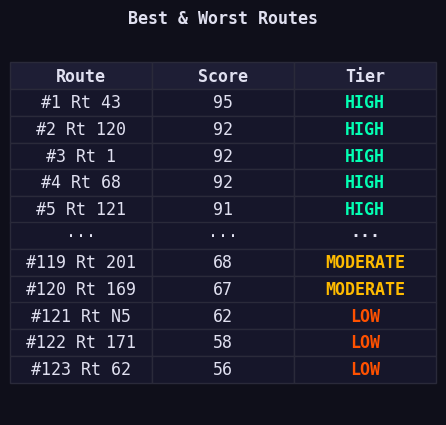

✓ Figure 2 saved


In [8]:
# =============================================================================
# FIGURE 2 — Best & Worst Routes Table
# =============================================================================

fig, ax = plt.subplots(figsize=(5, 5), facecolor=BG)
ax.set_facecolor(PANEL)
ax.axis('off')

table_data = []
for _, row in df_sorted.head(5).iterrows():
    table_data.append([f"#{row['rank']} Rt {row['route_id']}",
                       f"{row['bus_trust_score']:.0f}", row['trust_tier']])
table_data.append(['\u00b7\u00b7\u00b7', '\u00b7\u00b7\u00b7', '\u00b7\u00b7\u00b7'])
for _, row in df_sorted.tail(5).iterrows():
    table_data.append([f"#{row['rank']} Rt {row['route_id']}",
                       f"{row['bus_trust_score']:.0f}", row['trust_tier']])

tbl = ax.table(cellText=table_data, colLabels=['Route','Score','Tier'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.1, 1.6)

tier_color_map = {'HIGH': GREEN, 'MODERATE': YELLOW, 'LOW': ORANGE, 'CRITICAL': RED}
for (row_i, col_i), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL)
    cell.set_edgecolor('#2a2a3a')
    cell.set_text_props(color=WHITE)
    if row_i == 0:
        cell.set_facecolor('#1e1e35')
        cell.set_text_props(color=WHITE, fontweight='bold', fontsize=12)
    if col_i == 2 and row_i > 0:
        tier_val = table_data[row_i - 1][2]
        cell.set_text_props(color=tier_color_map.get(tier_val, WHITE), fontweight='bold')

ax.set_title('Best & Worst Routes', color=WHITE, fontsize=12, pad=5, fontweight='bold')
plt.savefig('pres_2_best&worst_routes.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 2 saved')

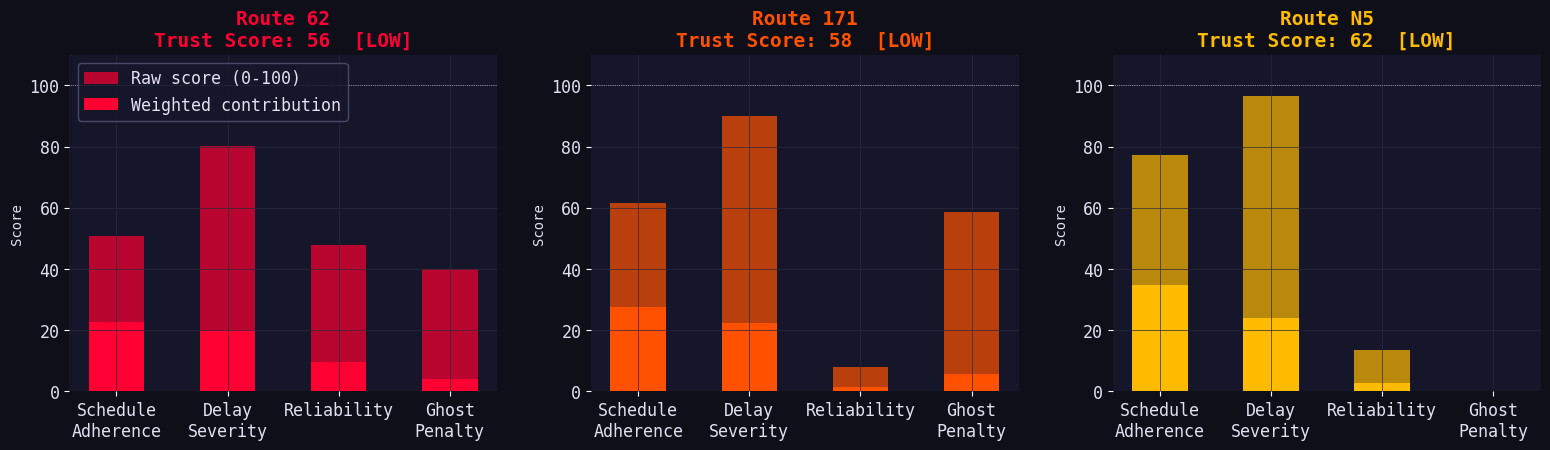

✓ Figure 3 saved


In [9]:
# =============================================================================
# FIGURE 3 — Worst 3 Routes: Pillar Breakdown
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)
ROUTE_COLORS = [RED, ORANGE, YELLOW]

for col_i, (route_id, rcolor) in enumerate(zip(WORST3, ROUTE_COLORS)):
    row_data = df[df['route_id'] == route_id].iloc[0]
    ax_top   = axes[col_i]

    pillars  = ['Schedule\nAdherence','Delay\nSeverity','Reliability','Ghost\nPenalty']
    scores_p = [row_data['p_otp'], row_data['p_severity'],
                row_data['p_reliability'], row_data['p_ghost']]
    weights  = [0.45, 0.25, 0.20, 0.10]
    contrib  = [s*w for s, w in zip(scores_p, weights)]
    x_p      = np.arange(len(pillars))

    ax_top.bar(x_p, scores_p, color=rcolor, alpha=0.7, width=0.5, label='Raw score (0-100)')
    ax_top.bar(x_p, contrib,  color=rcolor, alpha=1.0, width=0.5, label='Weighted contribution')
    ax_top.set_xticks(x_p)
    ax_top.set_xticklabels(pillars, fontsize=12)
    ax_top.set_ylim(0, 110)
    ax_top.set_ylabel('Score')
    ax_top.set_title(
        f'Route {route_id}\nTrust Score: {row_data["bus_trust_score"]:.0f}  [{row_data["trust_tier"]}]',
        color=rcolor, fontsize=14, fontweight='bold')
    ax_top.axhline(100, color=WHITE, lw=0.5, ls=':', alpha=1)
    if col_i == 0:
        ax_top.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY,
                      labelcolor=WHITE, loc='upper left')

for ax_ in axes.flat:
    ax_.set_facecolor(PANEL)
    ax_.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2.5)
plt.savefig('pres_3_worst_routes.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 3 saved')

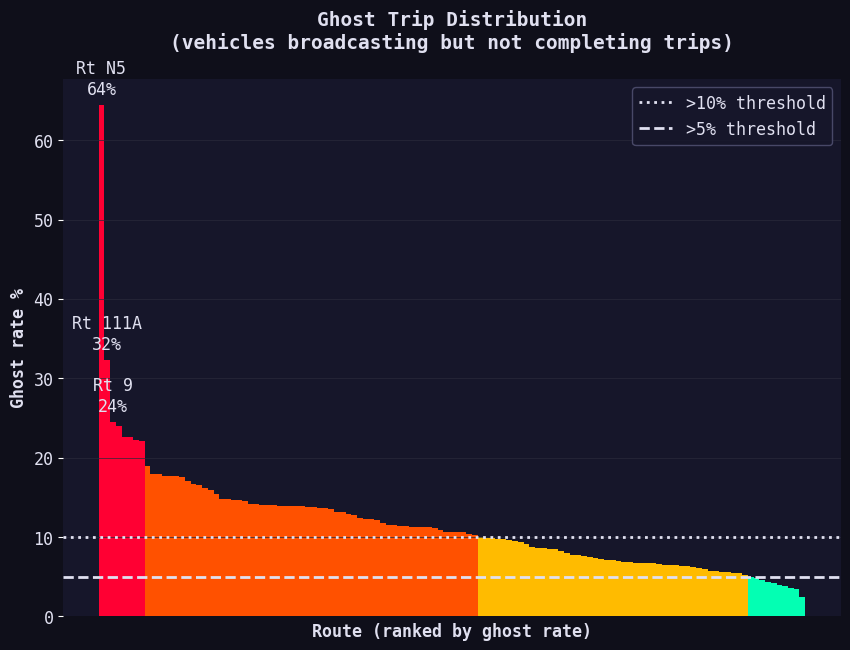

✓ Figure 4 saved


In [10]:
# =============================================================================
# FIGURE 4 — Ghost Trip Rate by Route
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)

ghost_sorted = df.sort_values('ghost_rate_pct', ascending=False).reset_index(drop=True)
x = np.arange(len(ghost_sorted))

ghost_colors = [RED if g > 20 else ORANGE if g > 10 else YELLOW if g > 5 else GREEN
                for g in ghost_sorted['ghost_rate_pct']]
ax.bar(x, ghost_sorted['ghost_rate_pct'], color=ghost_colors, alpha=1, width=1.0)

for i, row in ghost_sorted[ghost_sorted['ghost_rate_pct'] > 24].iterrows():
    ax.text(i, row['ghost_rate_pct'] + 0.8,
            f"Rt {row['route_id']}\n{row['ghost_rate_pct']:.0f}%",
            ha='center', va='bottom', color=WHITE, fontsize=12)

ax.axhline(10, color=WHITE, lw=2, ls='dotted', alpha=1, label='>10% threshold')
ax.axhline(5,  color=WHITE, lw=2, ls='--',     alpha=1, label='>5% threshold')
ax.set_xlabel('Route (ranked by ghost rate)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ghost rate %', fontsize=12, fontweight='bold')
ax.set_title('Ghost Trip Distribution\n(vehicles broadcasting but not completing trips)\n',
             color=WHITE, fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_xticks([])
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2.5)
plt.savefig('pres_4_ghost_distribution.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 4 saved')

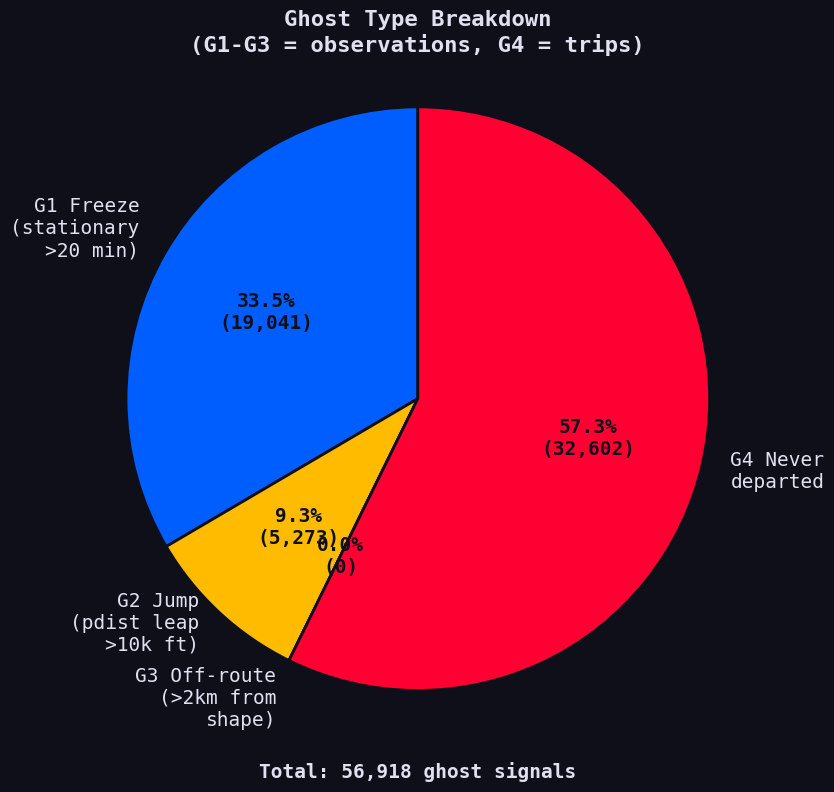

✓ Figure 5 saved


In [11]:
# =============================================================================
# FIGURE 5 — Ghost Type Breakdown
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)

ghost_obs = result[result['is_ghost']]
g1 = ghost_obs['ghost_freeze'].sum()
g2 = ghost_obs['ghost_jump'].sum()
g3 = ghost_obs['ghost_offroute'].sum()
g4 = (ghost_obs['match_type'] == 'ghost_trip').sum()

labels_g = ['G1 Freeze\n(stationary\n>20 min)\n',
            'G2 Jump\n(pdist leap\n>10k ft)\n',
            '\n\nG3 Off-route\n(>2km from\nshape)\n',
            'G4 Never\ndeparted']
values_g = [g1, g2, g3, g4]
colors_g = [BLUE, YELLOW, ORANGE, RED]

wedges, texts, autotexts = ax.pie(
    values_g, labels=labels_g, colors=colors_g,
    autopct=lambda p: f'{p:.1f}%\n({int(p/100*sum(values_g)):,})',
    startangle=90,
    wedgeprops=dict(width=1, edgecolor=BG, linewidth=2),
    textprops=dict(color=WHITE, fontsize=14),
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_color(BG)
    at.set_fontweight('bold')

ax.set_title('Ghost Type Breakdown\n(G1-G3 = observations, G4 = trips)',
             color=WHITE, fontsize=16, fontweight='bold')
ax.text(0, -1.3, f'Total: {sum(values_g):,} ghost signals',
        ha='center', color=WHITE, fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.axis('equal')
plt.savefig('pres_5_ghost_types.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 5 saved')

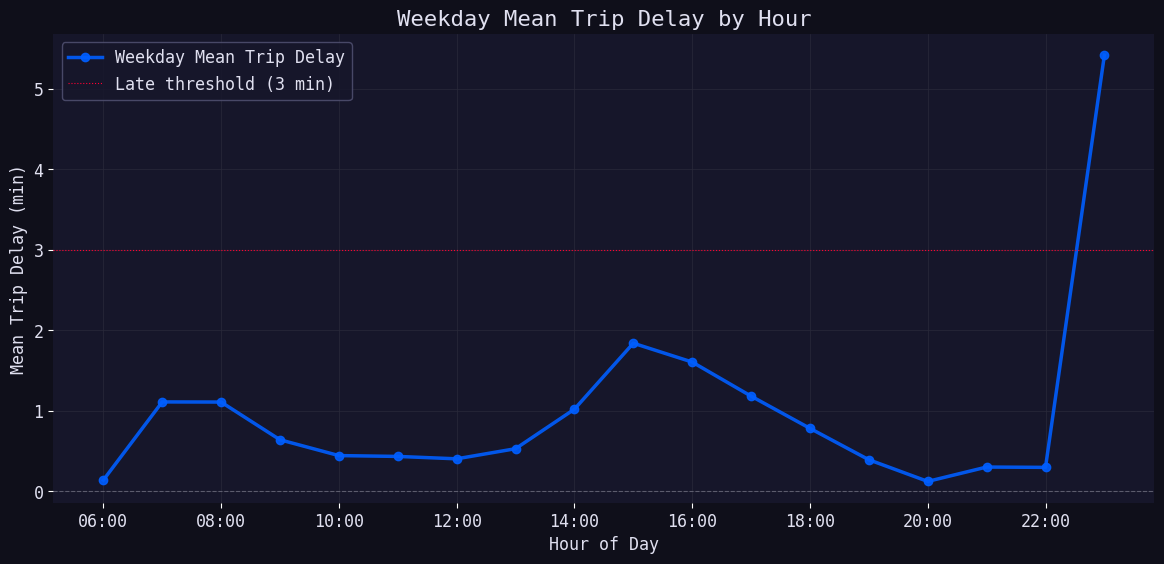

✓ Figure 6 saved


In [12]:
# =============================================================================
# FIGURE 6 — Weekday Mean Trip Delay by Hour
# =============================================================================

trips_wd    = trips[~trips['is_weekend'] & trips['hour'].notna() & (trips['hour'] >= 6)]
hourly_mean = trips_wd.groupby('hour')['delay_median'].mean()

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.plot(hourly_mean.index, hourly_mean.values,
        color=BLUE, lw=2.5, marker='o', markersize=6,
        label='Weekday Mean Trip Delay', alpha=0.9)
ax.axhline(0, color=WHITE, lw=0.8, ls='--', alpha=0.3)
ax.axhline(3, color=RED,   lw=0.8, ls=':',  alpha=1, label='Late threshold (3 min)')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Trip Delay (min)', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday Mean Trip Delay by Hour', fontsize=16, color=WHITE)
ax.set_facecolor(PANEL)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_6_weekday_mean_delay_by_hour.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 6 saved')

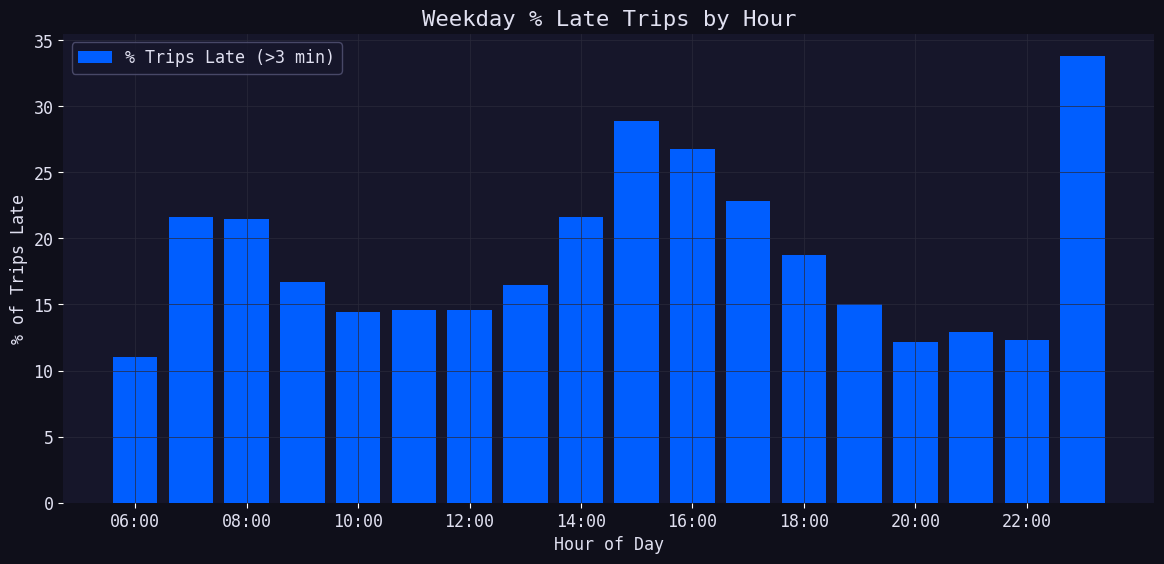

✓ Figure 7 saved


In [13]:
# =============================================================================
# FIGURE 7 — Weekday % Late Trips by Hour
# =============================================================================

hourly_pct_late = trips_wd.groupby('hour')['is_late'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.bar(hourly_pct_late.index, hourly_pct_late.values,
       width=0.8, color=BLUE, alpha=1, label='% Trips Late (>3 min)')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('% of Trips Late', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday % Late Trips by Hour', fontsize=16, color=WHITE)
ax.set_facecolor(PANEL)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_7_weekday_pct_late_by_hour.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 7 saved')

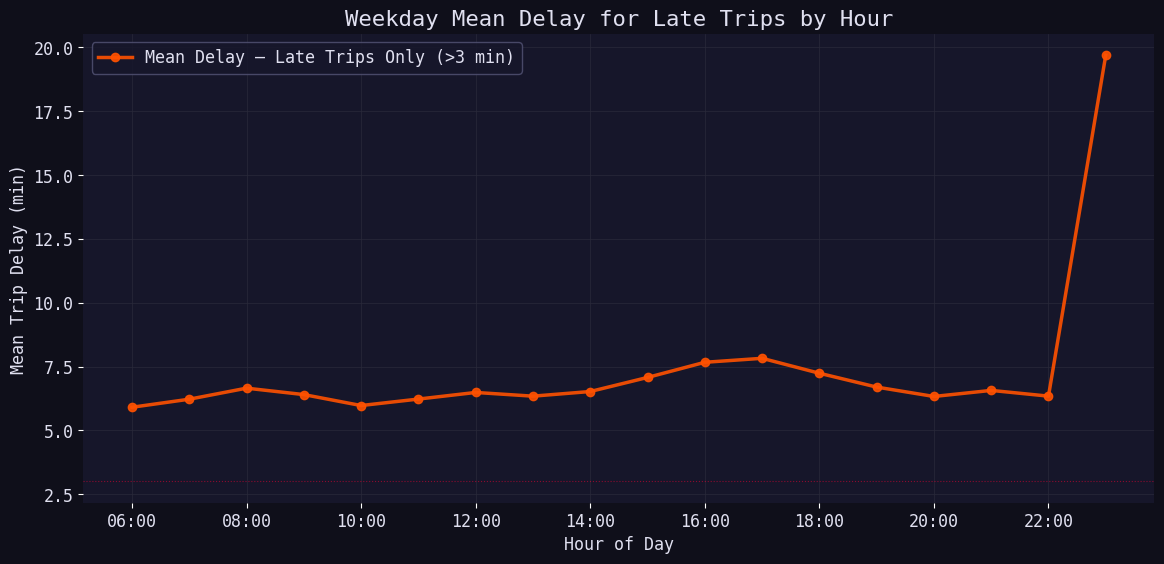

✓ Figure 8 saved


In [14]:
# =============================================================================
# FIGURE 8 — Weekday Mean Delay for Late Trips by Hour
# =============================================================================

hourly_mean_late = trips_wd[trips_wd['is_late']].groupby('hour')['delay_median'].mean()

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.plot(hourly_mean_late.index, hourly_mean_late.values,
        color=ORANGE, lw=2.5, marker='o', markersize=6,
        alpha=0.9, label='Mean Delay — Late Trips Only (>3 min)')
ax.axhline(3, color=RED, lw=0.8, ls=':', alpha=0.5)

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Mean Trip Delay (min)', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday Mean Delay for Late Trips by Hour', fontsize=16, color=WHITE)
ax.set_facecolor(PANEL)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_8_weekday_mean_late_delay_by_hour.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 8 saved')

# Route 201 Focus

In [15]:
# =============================================================================
# ROUTE 201 — Setup
# =============================================================================

# Observation-level subset (for stop corridor analysis)
r201 = clean[clean['route_id'] == '201'].copy()
r201['tmstmp_dt']      = pd.to_datetime(r201['tmstmp'])
r201['hour']           = r201['tmstmp_dt'].dt.hour
r201['dow']            = r201['tmstmp_dt'].dt.day_name()
r201['date']           = r201['tmstmp_dt'].dt.date
r201['sched_dep_hour'] = (r201['scheduled_departure_stop1'] // 60).astype('Int64')
r201['tod']            = r201['sched_dep_hour'].apply(
    lambda h: get_tod(h) if pd.notna(h) else get_tod(0)
)

# Trip-level subset — reuse trips df already computed
trips_201 = trips[trips['route_id'] == '201'].copy()

BUCKET_COLORS = [BLUE, GREEN, ORANGE, RED]
BUCKET_ORDER  = ['Early (<-1 min)', 'On Time (-1 to +3)', 'Late (3-15 min)', 'Very Late (>15 min)']

trips_201['otp_bucket'] = pd.cut(
    trips_201['delay_median'],
    bins=[-np.inf, -1, 3, 15, np.inf],
    labels=BUCKET_ORDER
)

r201_ghost_rate = perf.loc[perf['route_id'] == '201', 'ghost_rate_pct'].values[0]
r201_n_ghosts   = perf.loc[perf['route_id'] == '201', 'n_ghost_trips'].values[0]

print(f'Route 201 trips: {len(trips_201):,}')
print('\nOTP bucket counts (trip-level):')
print(trips_201['otp_bucket'].value_counts().reindex(BUCKET_ORDER))
print(f'\nGhost rate: {r201_ghost_rate:.1f}%  ({r201_n_ghosts:.0f} ghost trips)')

Route 201 trips: 841

OTP bucket counts (trip-level):
otp_bucket
Early (<-1 min)         60
On Time (-1 to +3)     420
Late (3-15 min)        345
Very Late (>15 min)     16
Name: count, dtype: int64

Ghost rate: 6.9%  (62 ghost trips)


In [16]:
# =============================================================================
# ROUTE 201 — Daily Median Delay per TOD  (trip-level)
# =============================================================================

daily_tod_median = (
    trips_201.groupby(['date', 'tod'], observed=True)['delay_median']
    .median()
    .reset_index()
)

daily_tod_median_pivot = (
    daily_tod_median
    .pivot(index='date', columns='tod', values='delay_median')
    .reindex(columns=TOD_ORDER)
)

print(daily_tod_median_pivot.round(1))

tod         Early Morning  AM Peak  Midday  PM Peak  Evening
date                                                        
2026-02-20            NaN      NaN     NaN      7.6      6.0
2026-02-21            NaN      1.3     2.5      2.8      2.1
2026-02-23           -0.9      1.4     1.4      2.0     -0.0
2026-02-24            1.2      2.2     2.0      2.4     -0.8
2026-02-25           -0.2      2.4     4.2      4.7      2.5
2026-02-26           -0.8      1.6     3.2      2.9      4.2
2026-02-27           -0.3      1.3     0.8      5.9      9.0
2026-02-28            NaN      0.2     2.8      4.0      0.4
2026-03-02           -0.4      1.4     1.7      2.0      3.2
2026-03-03            1.2      2.6     5.2      4.4      0.6
2026-03-04           -0.0      3.8     5.4      5.2      8.1
2026-03-05            0.0      2.1     4.2      2.2      2.5
2026-03-06            0.3      2.1     1.1      2.0      NaN


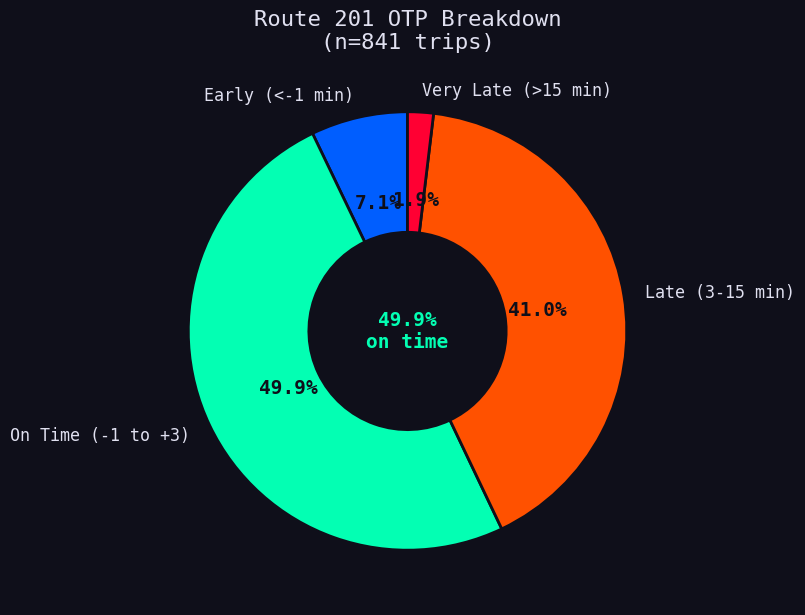

✓ Figure saved


In [17]:
# =============================================================================
# FIGURE — Route 201 OTP Breakdown  (trip-level donut)
# =============================================================================

bucket_counts = trips_201['otp_bucket'].value_counts().reindex(BUCKET_ORDER)
on_time_pct   = bucket_counts['On Time (-1 to +3)'] / bucket_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)

wedges, texts, autotexts = ax.pie(
    bucket_counts, labels=BUCKET_ORDER, colors=BUCKET_COLORS,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    textprops=dict(color=WHITE, fontsize=12)
)
for at, col in zip(autotexts, BUCKET_COLORS):
    at.set_color(BG)
    at.set_fontweight('bold')
    at.set_fontsize(14)

ax.set_title(f'Route 201 OTP Breakdown\n(n={bucket_counts.sum():,} trips)',
             color=WHITE, fontsize=16)
ax.text(0, 0, f'{on_time_pct:.1f}%\non time',
        ha='center', va='center', color=GREEN, fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)

plt.tight_layout()
plt.savefig('pres_201_otp_donut.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

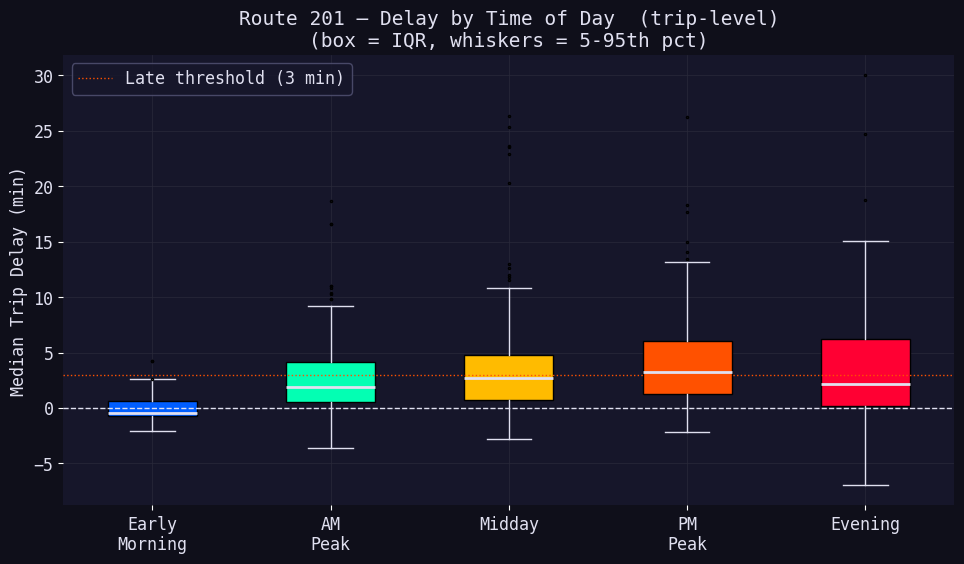

✓ Figure saved


In [18]:
# =============================================================================
# FIGURE — Route 201 Delay by Time of Day  (trip-level boxplot)
# =============================================================================

TOD_COLORS = [BLUE, GREEN, YELLOW, ORANGE, RED]
bp_data    = [trips_201[trips_201['tod'] == t]['delay_median'].clip(-15, 30).dropna()
              for t in TOD_ORDER]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                medianprops=dict(color=WHITE, lw=2),
                whiskerprops=dict(color=WHITE),
                capprops=dict(color=WHITE),
                flierprops=dict(marker='.', color=GREY, markersize=3, alpha=1))

for patch, col in zip(bp['boxes'], TOD_COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(1)

ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=12)
ax.set_ylabel('Median Trip Delay (min)', fontsize=12)
ax.set_title('Route 201 — Delay by Time of Day  (trip-level)\n(box = IQR, whiskers = 5-95th pct)',
             color=WHITE, fontsize=14)
ax.axhline(0, color=WHITE,  lw=1, ls='--', alpha=1)
ax.axhline(3, color=ORANGE, lw=1, ls=':',  alpha=1, label='Late threshold (3 min)')
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.savefig('pres_201_tod_boxplot.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

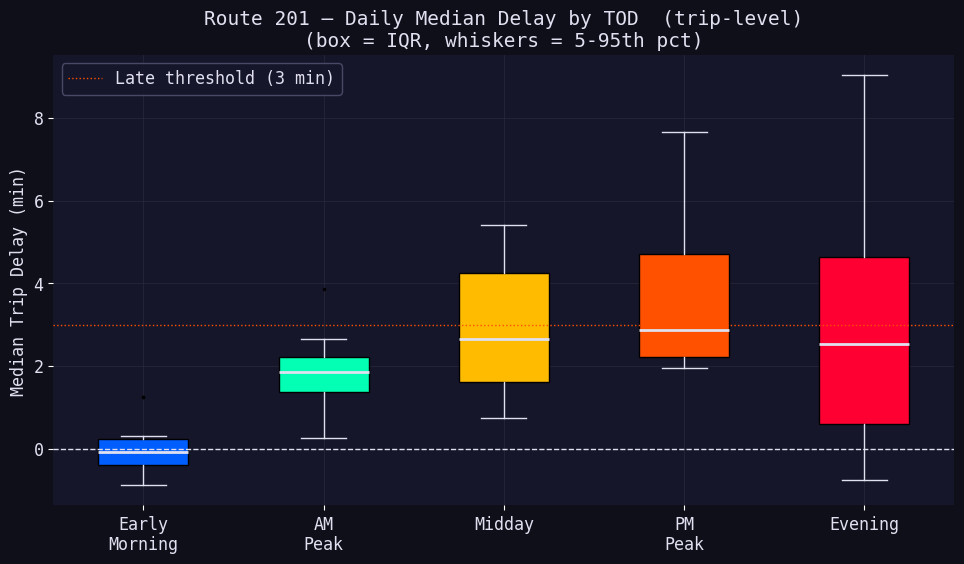

✓ Figure saved


In [19]:
# =============================================================================
# FIGURE — Route 201 Daily Median Delay by TOD  (trip-level)
# =============================================================================

TOD_COLORS       = [BLUE, GREEN, YELLOW, ORANGE, RED]
bp_data_grouped  = [daily_tod_median_pivot[t].dropna() for t in TOD_ORDER]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bp = ax.boxplot(bp_data_grouped, patch_artist=True, notch=False,
                medianprops=dict(color=WHITE, lw=2),
                whiskerprops=dict(color=WHITE),
                capprops=dict(color=WHITE),
                flierprops=dict(marker='.', color=GREY, markersize=3, alpha=1))

for patch, col in zip(bp['boxes'], TOD_COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(1)

ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=12)
ax.set_ylabel('Median Trip Delay (min)', fontsize=12)
ax.set_title('Route 201 — Daily Median Delay by TOD  (trip-level)\n(box = IQR, whiskers = 5-95th pct)',
             color=WHITE, fontsize=14)
ax.axhline(0, color=WHITE,  lw=1, ls='--', alpha=1)
ax.axhline(3, color=ORANGE, lw=1, ls=':',  alpha=1, label='Late threshold (3 min)')
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_201_daily_tod_boxplot.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

## Route 201 — Stop-Level Analysis  (observation-level)

In [20]:
# =============================================================================
# ROUTE 201 — Stop columns check
# =============================================================================

stop_cols = [c for c in clean.columns if any(x in c.lower()
             for x in ['stop','stpid','stpnm','next','prev'])]
print('Stop-related columns:', stop_cols)
print('\nSample prev_stop_name values:')
print(r201['prev_stop_name'].value_counts().head(10))
print('\nSample next_stop_name values:')
print(r201['next_stop_name'].value_counts().head(10))

Stop-related columns: ['stop_id', 'first_stop_name', 'scheduled_departure_stop1', 'prev_stop_name', 'next_stop_name']

Sample prev_stop_name values:
prev_stop_name
Old Orchard Rd & Skokie Blvd        2103
Rogers & Hermitage                  1474
Paulina & Howard Terminal            873
Sheridan & Lincoln                   667
4700 W Old Orchard Rd                655
Church & Chicago Avenue              626
Sheridan & Haven                     625
Sheridan & Foster                    550
Central Street & Crawford            495
Old Orchard Mall - Bloomingdales     475
Name: count, dtype: int64

Sample next_stop_name values:
next_stop_name
Old Orchard Mall - Macys        1988
Paulina & Howard Terminal       1474
Howard & Chicago Avenue          873
Central Street & Crawford        814
Old Orchard Rd & Skokie Blvd     689
Sheridan & Lincoln               662
Sheridan & Haven                 649
Sheridan & Emerson               626
Howard & Ridge                   624
Ridge & Oakton       

In [21]:
# =============================================================================
# ROUTE 201 — Sheridan Corridor Stop Summary
# =============================================================================

STOPS = {
    'Sheridan & Emerson': ('NB',   'Emerson'),
    'Sheridan & Foster':  ('NB/SB','Foster'),
    'Sheridan & Haven':   ('NB/SB','Haven'),
    'Sheridan & Lincoln': ('NB/SB','Lincoln'),
}

r201_stops = r201[
    r201['next_stop_name'].isin(STOPS.keys()) |
    r201['prev_stop_name'].isin(STOPS.keys())
].copy()

r201_stops['stop_name'] = np.where(
    r201_stops['next_stop_name'].isin(STOPS.keys()),
    r201_stops['next_stop_name'],
    r201_stops['prev_stop_name']
)
r201_stops['at_stop_type'] = np.where(
    r201_stops['next_stop_name'].isin(STOPS.keys()),
    'approaching', 'departed'
)

print('Observations per stop:')
print(r201_stops.groupby(['stop_name','at_stop_type']).size().unstack(fill_value=0))
print('\nDelay summary per stop:')
print(r201_stops.groupby('stop_name')['delay_minutes']
      .agg(['count','median','mean','std']).round(2))

Observations per stop:
at_stop_type        approaching  departed
stop_name                                
Sheridan & Emerson          626         0
Sheridan & Foster           408       300
Sheridan & Haven            649         0
Sheridan & Lincoln          662       268

Delay summary per stop:
                    count  median  mean   std
stop_name                                    
Sheridan & Emerson    626     4.0  4.52  3.77
Sheridan & Foster     708     2.1  2.98  4.69
Sheridan & Haven      649     2.6  3.25  4.49
Sheridan & Lincoln    930     3.6  4.09  4.52


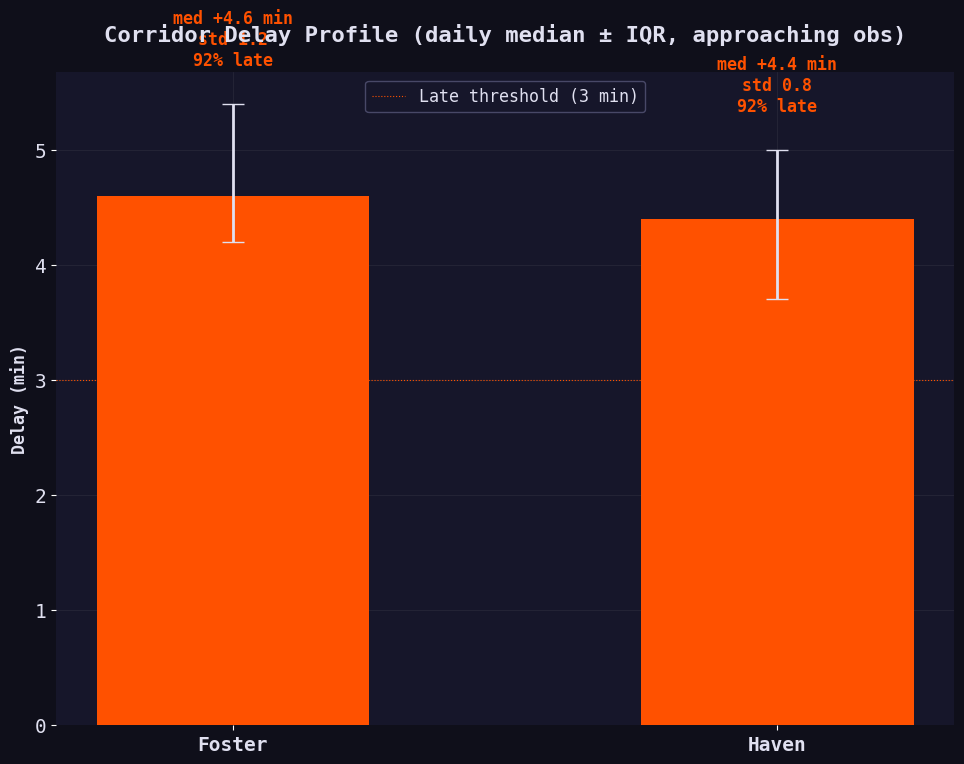

✓ Figure saved


In [22]:
# =============================================================================
# FIGURE — Route 201 Corridor Delay Profile
# =============================================================================

STOP_ORDER = ['Sheridan & Foster', 'Sheridan & Haven']
STOP_SHORT = ['Foster', 'Haven']

r201_appr = r201_stops[
    (r201_stops['at_stop_type'] == 'approaching') &
    (r201_stops['des'] == 'Old Orchard')
].copy()

daily_stop_median = (
    r201_appr.groupby(['date', 'stop_name'])['delay_minutes']
    .median().reset_index()
)

stop_stats = (
    daily_stop_median.groupby('stop_name')['delay_minutes']
    .agg(['median','mean','std',
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75),
          lambda x: (x > 3).mean() * 100,
          lambda x: (x > 15).mean() * 100,
          'count'])
    .reindex(STOP_ORDER)
)
stop_stats.columns = ['median','mean','std','q25','q75','pct_late','pct_very_late','n']

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
x        = np.arange(len(STOP_ORDER))
bar_cols = [ORANGE, ORANGE]

ax.bar(x, stop_stats['median'], color=bar_cols, alpha=1, width=0.5, zorder=3)
ax.errorbar(x, stop_stats['median'],
            yerr=[stop_stats['median'] - stop_stats['q25'],
                  stop_stats['q75']    - stop_stats['median']],
            fmt='none', color=WHITE, capsize=8, lw=2, zorder=4)

for i, (s, row) in enumerate(stop_stats.iterrows()):
    ax.text(i, row['q75'] + 0.3,
            f"med {row['median']:+.1f} min\nstd {row['std']:.1f}\n{row['pct_late']:.0f}% late",
            ha='center', va='bottom', fontsize=12, color=bar_cols[i], fontweight='bold')

ax.axhline(0, color=WHITE,  lw=0.7, ls='--', alpha=1)
ax.axhline(3, color=ORANGE, lw=0.8, ls=':',  alpha=1, label='Late threshold (3 min)')
ax.set_xticks(x)
ax.set_xticklabels(STOP_SHORT, fontsize=12, fontweight='bold')
ax.set_ylabel('Delay (min)', color=WHITE, fontsize=12, fontweight='bold')
ax.set_title('Corridor Delay Profile (daily median \u00b1 IQR, approaching obs)\n',
             color=WHITE, fontsize=16, fontweight='bold')
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=14, labelcolor=WHITE)
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.savefig('pres_201_corridor_delay_profile.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

In [23]:
metrics = pd.read_csv('metrics_results/final_metrics_dataset.csv')

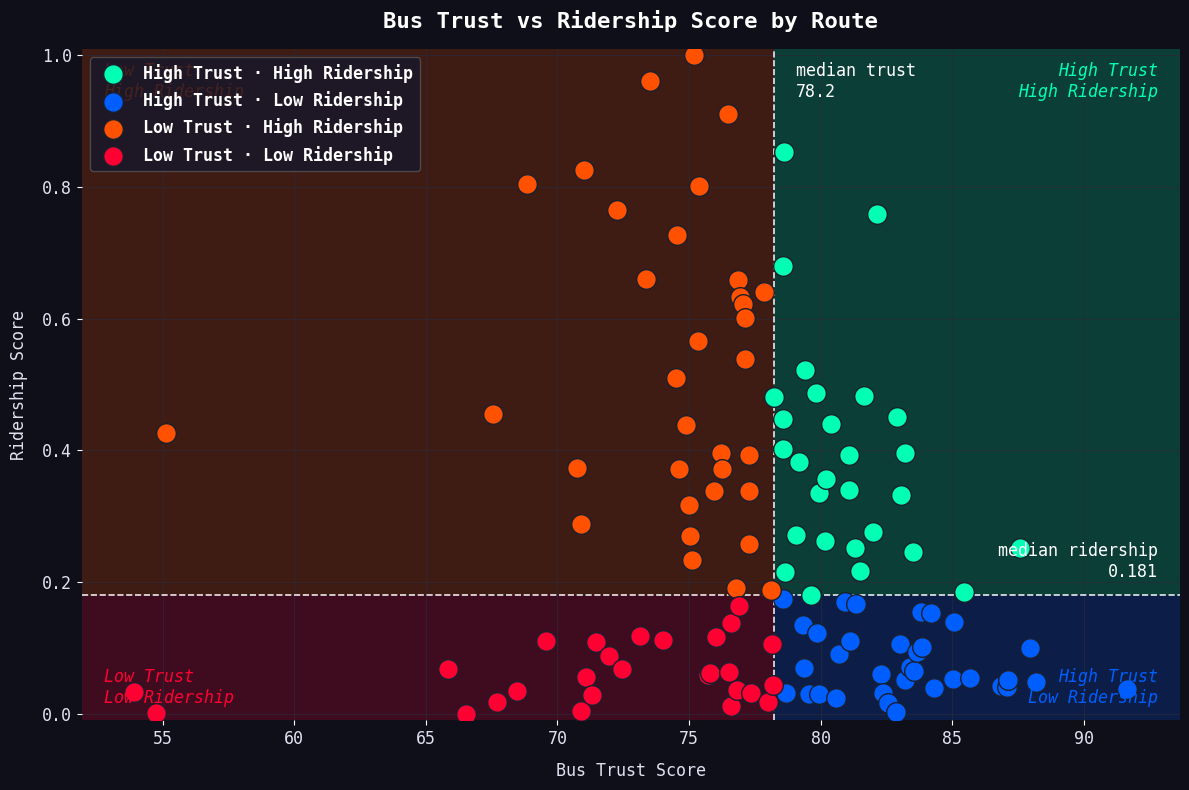

✓ Figure saved


In [24]:
# =============================================================================
# FIGURE — Bus Trust Score vs Ridership Score
# =============================================================================

df_m = metrics.copy()

trust_mid     = df_m['bus_trust_score'].median()
ridership_mid = df_m['ridership_score'].median()

def assign_quadrant(row):
    hi_t = row['bus_trust_score'] >= trust_mid
    hi_r = row['ridership_score']  >= ridership_mid
    if   hi_t and hi_r:     return 'High Trust\nHigh Ridership'
    elif hi_t and not hi_r: return 'High Trust\nLow Ridership'
    elif not hi_t and hi_r: return 'Low Trust\nHigh Ridership'
    else:                   return 'Low Trust\nLow Ridership'

df_m['quadrant'] = df_m.apply(assign_quadrant, axis=1)

quad_colors = {
    'High Trust\nHigh Ridership': GREEN,
    'High Trust\nLow Ridership':  BLUE,
    'Low Trust\nHigh Ridership':  ORANGE,
    'Low Trust\nLow Ridership':   RED,
}
quad_labels = {
    'High Trust\nHigh Ridership': 'High Trust · High Ridership',
    'High Trust\nLow Ridership':  'High Trust · Low Ridership',
    'Low Trust\nHigh Ridership':  'Low Trust · High Ridership',
    'Low Trust\nLow Ridership':   'Low Trust · Low Ridership',
}

fig, ax = plt.subplots(figsize=(12, 8))

xlim = (df_m['bus_trust_score'].min()-2, df_m['bus_trust_score'].max()+2)
ylim = (df_m['ridership_score'].min()-0.01, df_m['ridership_score'].max()+0.01)

shade_quads = [
    (xlim[0], trust_mid,  ylim[0], ridership_mid, RED,    0.2),
    (trust_mid, xlim[1],  ylim[0], ridership_mid, BLUE,   0.2),
    (xlim[0], trust_mid,  ridership_mid, ylim[1], ORANGE, 0.2),
    (trust_mid, xlim[1],  ridership_mid, ylim[1], GREEN,  0.2),
]
for x0, x1, y0, y1, c, a in shade_quads:
    ax.add_patch(mpatches.Rectangle((x0,y0), x1-x0, y1-y0,
                                    facecolor=c, alpha=a, zorder=1))

for quad, color in quad_colors.items():
    subset = df_m[df_m['quadrant'] == quad]
    ax.scatter(subset['bus_trust_score'], subset['ridership_score'],
               c=color, s=200, alpha=1, edgecolors='#1a1f2e', linewidths=1,
               label=quad_labels[quad], zorder=3)

ax.axvline(trust_mid,     color='white', lw=1.2, ls='--', alpha=0.9, zorder=2)
ax.axhline(ridership_mid, color='white', lw=1.2, ls='--', alpha=0.9, zorder=2)

pad_x = (xlim[1]-xlim[0])*0.02
pad_y = (ylim[1]-ylim[0])*0.02
corner_labels = [
    (xlim[0]+pad_x, ylim[0]+pad_y, 'Low Trust\nLow Ridership',   RED,    'left',  'bottom'),
    (xlim[1]-pad_x, ylim[0]+pad_y, 'High Trust\nLow Ridership',  BLUE,   'right', 'bottom'),
    (xlim[0]+pad_x, ylim[1]-pad_y, 'Low Trust\nHigh Ridership',  ORANGE, 'left',  'top'),
    (xlim[1]-pad_x, ylim[1]-pad_y, 'High Trust\nHigh Ridership', GREEN,  'right', 'top'),
]
for cx, cy, text, color, ha, va in corner_labels:
    ax.text(cx, cy, text, color=color, fontsize=12,
            ha=ha, va=va, fontstyle='italic', zorder=4)

ax.text(trust_mid+pad_x,  ylim[1]-pad_y,
        f'median trust\n{trust_mid:.1f}',
        color='white', fontsize=12, ha='left', va='top')
ax.text(xlim[1]-pad_x, ridership_mid+pad_y,
        f'median ridership\n{ridership_mid:.3f}',
        color='white', fontsize=12, ha='right', va='bottom')

ax.set_xlabel('Bus Trust Score', fontsize=12, labelpad=10)
ax.set_ylabel('Ridership Score',  fontsize=12, labelpad=10)
ax.set_title('Bus Trust vs Ridership Score by Route',
             fontsize=16, fontweight='bold', pad=15)

leg = ax.legend(loc='upper left', fontsize=12, facecolor=PANEL,
                edgecolor='#555', labelcolor='white')
for text in leg.get_texts():
    text.set_fontweight('bold')

ax.grid(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout()
plt.savefig('pres_11_trust_vs_ridership.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

# Summary Statistics

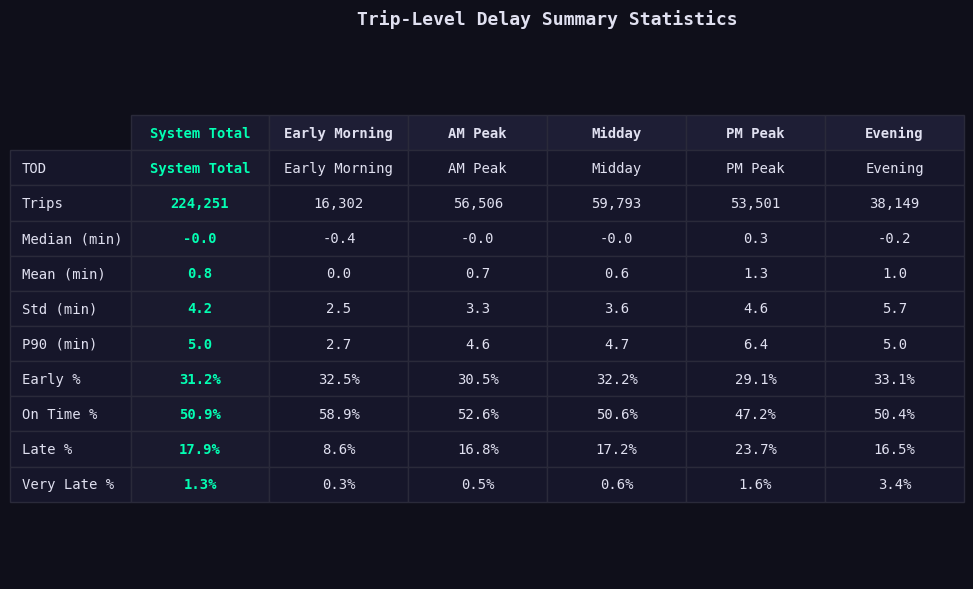

✓ Transposed summary stats table saved


In [39]:
# =============================================================================
# FIGURE — Trip-Level Delay Summary Statistics Table (TRANSPOSED)
# =============================================================================

import matplotlib.gridspec as gridspec

# Overall row
overall_row = {
    'TOD':           'System Total',
    'Trips':         f"{len(trips):,}",
    'Median (min)':  f"{trips['delay_median'].median():.1f}",
    'Mean (min)':    f"{trips['delay_median'].mean():.1f}",
    'Std (min)':     f"{trips['delay_median'].std():.1f}",
    'P90 (min)':     f"{trips['delay_median'].quantile(0.9):.1f}",
    'Early %':       f"{trips['is_early'].mean()*100:.1f}%",
    'On Time %':     f"{trips['is_ontime'].mean()*100:.1f}%",
    'Late %':        f"{trips['is_late'].mean()*100:.1f}%",
    'Very Late %':   f"{trips['is_very_late'].mean()*100:.1f}%",
}

# TOD rows
tod_rows = []
for tod in TOD_ORDER:
    t = trips[trips['tod'] == tod]
    if len(t) == 0:
        continue
    tod_rows.append({
        'TOD':           tod,
        'Trips':         f"{len(t):,}",
        'Median (min)':  f"{t['delay_median'].median():.1f}",
        'Mean (min)':    f"{t['delay_median'].mean():.1f}",
        'Std (min)':     f"{t['delay_median'].std():.1f}",
        'P90 (min)':     f"{t['delay_median'].quantile(0.9):.1f}",
        'Early %':       f"{t['is_early'].mean()*100:.1f}%",
        'On Time %':     f"{t['is_ontime'].mean()*100:.1f}%",
        'Late %':        f"{t['is_late'].mean()*100:.1f}%",
        'Very Late %':   f"{t['is_very_late'].mean()*100:.1f}%",
    })

all_rows = [overall_row] + tod_rows
cols = list(overall_row.keys())

# Original table data
tbl_data = [[r[c] for c in cols] for r in all_rows]

# ---- TRANSPOSE ----
row_labels = cols
col_labels = [r['TOD'] for r in all_rows]

tbl_data_t = list(map(list, zip(*tbl_data)))

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(PANEL)
ax.axis('off')

tbl = ax.table(
    cellText=tbl_data_t,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

for (row_i, col_i), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL)
    cell.set_edgecolor('#2a2a3a')
    cell.set_text_props(color=WHITE)

    if row_i == 0:  # column headers
        cell.set_facecolor('#1e1e35')
        cell.set_text_props(color=WHITE, fontweight='bold')

    if col_i == 0:  # system total column
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color=GREEN, fontweight='bold')

ax.set_title('Trip-Level Delay Summary Statistics', color=WHITE,
             fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('report_1_summary_stats_table_transposed.png', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.show()

print('\u2713 Transposed summary stats table saved')


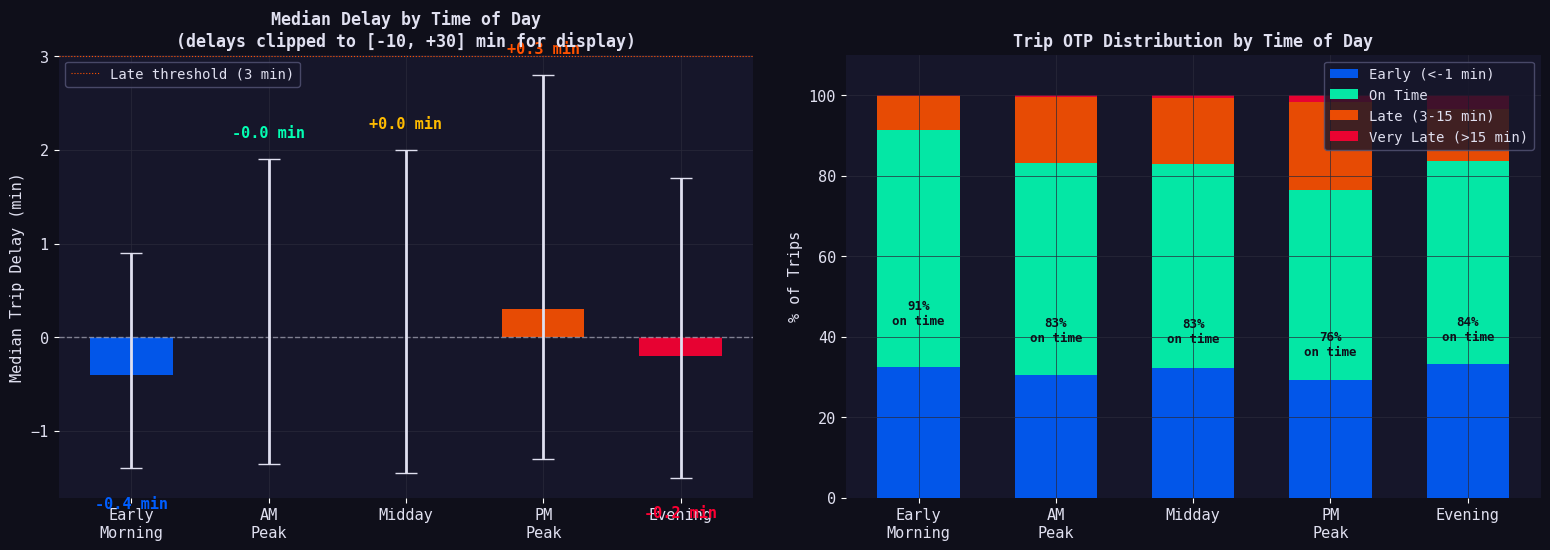

✓ TOD delay figure saved

TOD summary:
               delay_median  delay_q25  delay_q75  pct_ontime  pct_late  pct_very_late  n_trips
tod                                                                                            
Early Morning          -0.4       -1.4        0.9        58.9       8.6            0.3    16302
AM Peak                -0.0       -1.4        1.9        52.6      16.8            0.5    56506
Midday                  0.0       -1.5        2.0        50.6      17.2            0.6    59793
PM Peak                 0.3       -1.3        2.8        47.2      23.7            1.6    53501
Evening                -0.2       -1.5        1.7        50.4      16.5            3.4    38149


In [38]:
# =============================================================================
# FIGURE — Median Trip Delay and OTP Distribution by Time of Day
# IQR computed on clipped delays to avoid outlier distortion
# =============================================================================

TOD_COLORS = [BLUE, GREEN, YELLOW, ORANGE, RED]

# Clip extreme delays before computing spread — outliers distort IQR badly
trips_clipped = trips.copy()
trips_clipped['delay_clipped'] = trips_clipped['delay_median'].clip(-10, 30)

tod_plot = (
    trips_clipped.groupby('tod', observed=True)
    .agg(
        delay_median  = ('delay_clipped', 'median'),
        delay_q25     = ('delay_clipped', lambda x: x.quantile(0.25)),
        delay_q75     = ('delay_clipped', lambda x: x.quantile(0.75)),
        pct_late      = ('is_late',       lambda x: x.mean() * 100),
        pct_very_late = ('is_very_late',  lambda x: x.mean() * 100),
        pct_early     = ('is_early',      lambda x: x.mean() * 100),
        pct_ontime    = ('is_ontime',     lambda x: x.mean() * 100),
        n_trips       = ('delay_clipped', 'count'),
    )
    .reindex(TOD_ORDER)
)

x     = np.arange(len(TOD_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)

# ── Left: median delay with IQR error bars ────────────────────────────────
ax = axes[0]
bars = ax.bar(x, tod_plot['delay_median'], color=TOD_COLORS, alpha=0.9, width=0.6)
ax.errorbar(x, tod_plot['delay_median'],
            yerr=[tod_plot['delay_median'] - tod_plot['delay_q25'],
                  tod_plot['delay_q75']    - tod_plot['delay_median']],
            fmt='none', color=WHITE, capsize=8, lw=2, zorder=4)

for i, (tod, row) in enumerate(tod_plot.iterrows()):
    offset = row['delay_q75'] + 0.2 if row['delay_median'] >= 0 else row['delay_q25'] - 0.3
    ax.text(i, offset, f"{row['delay_median']:+.1f} min",
            ha='center', va='bottom' if row['delay_median'] >= 0 else 'top',
            fontsize=11, color=TOD_COLORS[i], fontweight='bold')

ax.axhline(0, color=WHITE,  lw=1,   ls='--', alpha=0.5)
ax.axhline(3, color=ORANGE, lw=0.8, ls=':',  alpha=1, label='Late threshold (3 min)')
ax.set_xticks(x)
ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=11)
ax.set_ylabel('Median Trip Delay (min)', fontsize=11)
ax.set_title('Median Delay by Time of Day\n(delays clipped to [-10, +30] min for display)',
             color=WHITE, fontsize=12, fontweight='bold')
ax.legend(fontsize=10, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=11, labelcolor=WHITE)

# ── Right: stacked OTP breakdown ──────────────────────────────────────────
ax = axes[1]
pct_late_only = tod_plot['pct_late'] - tod_plot['pct_very_late']

b1 = ax.bar(x, tod_plot['pct_early'],    color=BLUE,   alpha=0.9, width=0.6, label='Early (<-1 min)')
b2 = ax.bar(x, tod_plot['pct_ontime'],   color=GREEN,  alpha=0.9, width=0.6,
            bottom=tod_plot['pct_early'], label='On Time')
b3 = ax.bar(x, pct_late_only,            color=ORANGE, alpha=0.9, width=0.6,
            bottom=tod_plot['pct_early'] + tod_plot['pct_ontime'], label='Late (3-15 min)')
b4 = ax.bar(x, tod_plot['pct_very_late'],color=RED,    alpha=0.9, width=0.6,
            bottom=tod_plot['pct_early'] + tod_plot['pct_ontime'] + pct_late_only,
            label='Very Late (>15 min)')

# Annotate OTP % on top of on-time segment
for i, (tod, row) in enumerate(tod_plot.iterrows()):
    otp = row['pct_early'] + row['pct_ontime']
    ax.text(i, otp / 2, f"{otp:.0f}%\non time",
            ha='center', va='center', fontsize=9,
            color=BG, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=11)
ax.set_ylabel('% of Trips', fontsize=11)
ax.set_title('Trip OTP Distribution by Time of Day',
             color=WHITE, fontsize=12, fontweight='bold')
ax.legend(fontsize=10, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE, loc='upper right')
ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=11, labelcolor=WHITE)
ax.set_ylim(0, 110)

plt.tight_layout(pad=2.5)
plt.savefig('report_2_delay_by_tod.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 TOD delay figure saved')

# Print the numbers for the report text
print('\nTOD summary:')
print(tod_plot[['delay_median','delay_q25','delay_q75','pct_ontime','pct_late','pct_very_late','n_trips']].round(1).to_string())

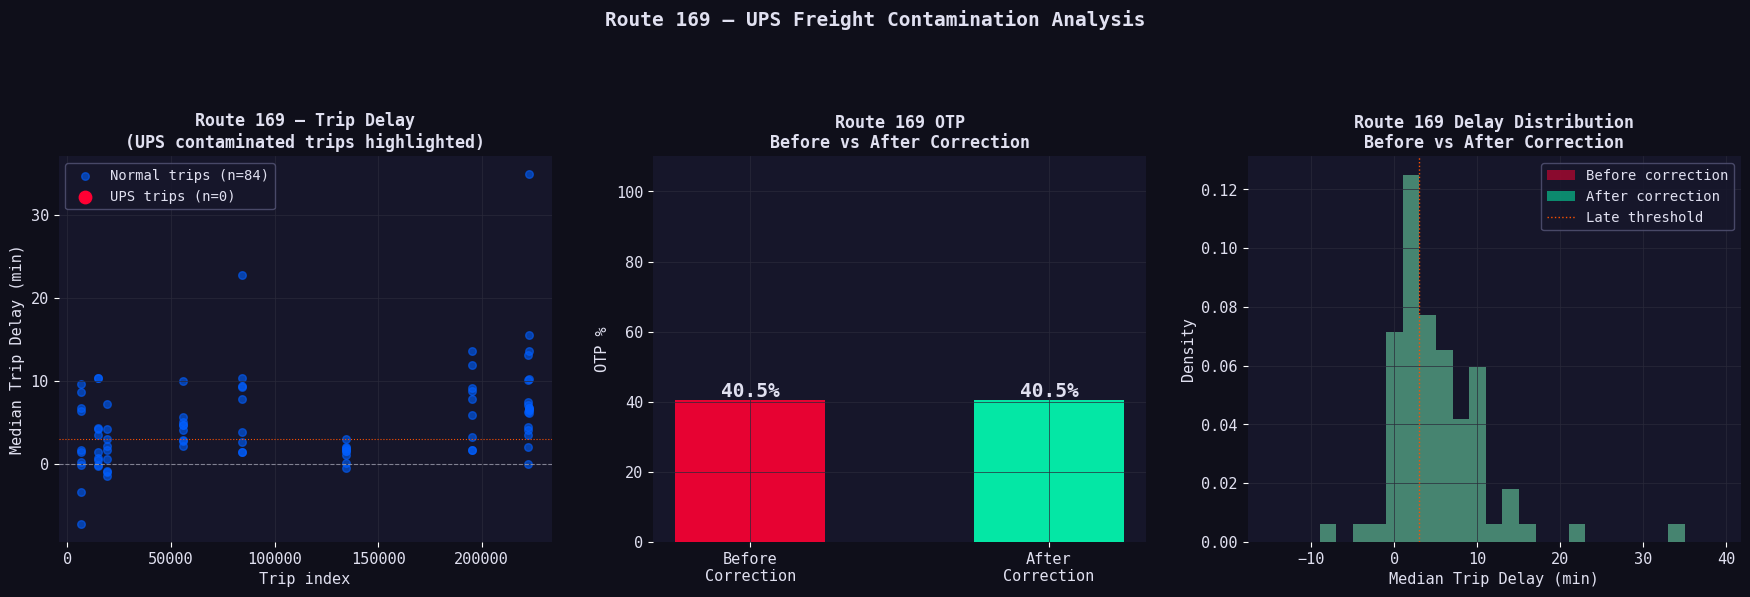

UPS trips found       : 0
OTP before correction : 40.5%
OTP after correction  : 40.5%
✓ Route 169 figure saved


In [35]:
# =============================================================================
# FIGURE — Route 169 UPS Contamination
# Shows delay distribution before/after removing contaminated trips,
# and highlights which trips are the outliers.
# =============================================================================

UPS_TRIPS = ['6770050121020','6770043866020','6770001509020',
             '6770012465020','6770050008020']

r169       = clean[clean['route_id'] == '169'].copy()
trips_169  = trips[trips['route_id'] == '169'].copy()
trips_169['is_ups'] = trips_169['matched_trip_id'].isin(UPS_TRIPS)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=BG)

# ── Left: delay scatter coloured by UPS vs normal ────────────────────────
ax = axes[0]
normal = trips_169[~trips_169['is_ups']]
ups    = trips_169[trips_169['is_ups']]

ax.scatter(normal.index, normal['delay_median'], color=BLUE,
           alpha=0.6, s=30, label=f'Normal trips (n={len(normal):,})')
ax.scatter(ups.index,    ups['delay_median'],    color=RED,
           alpha=1,   s=80, label=f'UPS trips (n={len(ups):,})', zorder=5)

ax.axhline(0, color=WHITE,  lw=0.8, ls='--', alpha=0.5)
ax.axhline(3, color=ORANGE, lw=0.8, ls=':',  alpha=1)
ax.set_xlabel('Trip index', fontsize=11)
ax.set_ylabel('Median Trip Delay (min)', fontsize=11)
ax.set_title('Route 169 — Trip Delay\n(UPS contaminated trips highlighted)',
             color=WHITE, fontsize=12, fontweight='bold')
ax.legend(fontsize=10, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_facecolor(PANEL)
ax.tick_params(labelsize=11, labelcolor=WHITE)

# ── Middle: OTP comparison before vs after ───────────────────────────────
ax = axes[1]
otp_before = (trips_169['delay_median'].between(-1, 3)).mean() * 100
otp_after  = (normal['delay_median'].between(-1, 3)).mean() * 100

bars = ax.bar(['Before\nCorrection', 'After\nCorrection'],
              [otp_before, otp_after],
              color=[RED, GREEN], alpha=0.9, width=0.5)

for bar, val in zip(bars, [otp_before, otp_after]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1,
            f'{val:.1f}%', ha='center', fontsize=14,
            color=WHITE, fontweight='bold')

ax.set_ylabel('OTP %', fontsize=11)
ax.set_title('Route 169 OTP\nBefore vs After Correction',
             color=WHITE, fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_facecolor(PANEL)
ax.tick_params(labelsize=11, labelcolor=WHITE)

# ── Right: delay distribution comparison ─────────────────────────────────
ax = axes[2]
bins = np.arange(-15, 40, 2)
ax.hist(trips_169['delay_median'], bins=bins, color=RED,
        alpha=0.5, label='Before correction', density=True)
ax.hist(normal['delay_median'],    bins=bins, color=GREEN,
        alpha=0.5, label='After correction',  density=True)

ax.axvline(3, color=ORANGE, lw=1, ls=':', alpha=1, label='Late threshold')
ax.set_xlabel('Median Trip Delay (min)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Route 169 Delay Distribution\nBefore vs After Correction',
             color=WHITE, fontsize=12, fontweight='bold')
ax.legend(fontsize=10, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_facecolor(PANEL)
ax.tick_params(labelsize=11, labelcolor=WHITE)

plt.suptitle('Route 169 — UPS Freight Contamination Analysis',
             color=WHITE, fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.savefig('report_3_route169_correction.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()

print(f'UPS trips found       : {len(ups):,}')
print(f'OTP before correction : {otp_before:.1f}%')
print(f'OTP after correction  : {otp_after:.1f}%')
print('\u2713 Route 169 figure saved')

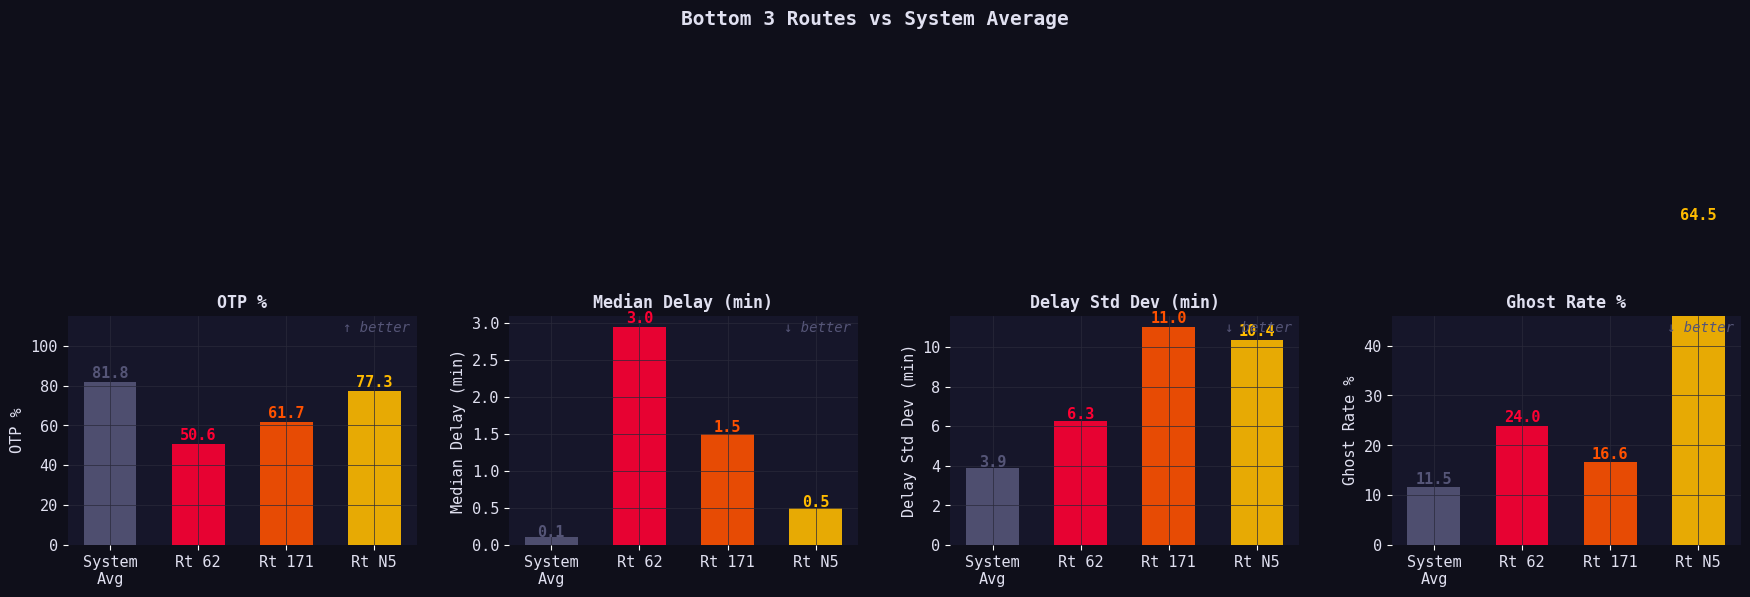

✓ Bottom 3 stats figure saved


In [36]:
# =============================================================================
# FIGURE — Bottom 3 Routes: Raw Stats vs System Average
# Four metrics side by side: OTP, median delay, delay std, ghost rate
# Each group shows system avg + worst 3 routes
# =============================================================================

metrics_to_plot = [
    ('overall_otp_pct',      'OTP %',               True,  100),   # higher is better
    ('overall_delay_median', 'Median Delay (min)',   False, None),  # lower is better
    ('overall_delay_std',    'Delay Std Dev (min)',  False, None),
    ('ghost_rate_pct',       'Ghost Rate %',         False, 40),
]

system_avg = df[['overall_otp_pct','overall_delay_median',
                 'overall_delay_std','ghost_rate_pct']].mean()

bottom3_df = df[df['route_id'].isin(WORST3)].set_index('route_id')

fig, axes = plt.subplots(1, 4, figsize=(18, 6), facecolor=BG)
ROUTE_COLORS_MAP = {WORST3[0]: RED, WORST3[1]: ORANGE, WORST3[2]: YELLOW}

for ax_i, (col, label, higher_better, ylim) in enumerate(metrics_to_plot):
    ax = axes[ax_i]

    # System average bar
    sys_val = system_avg[col]
    ax.bar(0, sys_val, color=GREY, alpha=0.9, width=0.6, label='System avg')
    ax.text(0, sys_val + (ylim or sys_val)*0.02 if ylim else sys_val*1.02,
            f'{sys_val:.1f}', ha='center', fontsize=11,
            color=GREY, fontweight='bold')

    # Bottom 3 bars
    for j, route_id in enumerate(WORST3):
        val   = bottom3_df.loc[route_id, col]
        color = ROUTE_COLORS_MAP[route_id]
        ax.bar(j+1, val, color=color, alpha=0.9, width=0.6, label=f'Rt {route_id}')
        ax.text(j+1, val + (ylim or val)*0.02 if ylim else val*1.02,
                f'{val:.1f}', ha='center', fontsize=11,
                color=color, fontweight='bold')

    ax.set_xticks(range(4))
    ax.set_xticklabels(['System\nAvg'] + [f'Rt {r}' for r in WORST3], fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(label, color=WHITE, fontsize=12, fontweight='bold')
    if ylim:
        ax.set_ylim(0, ylim * 1.15)
    ax.set_facecolor(PANEL)
    ax.tick_params(labelsize=11, labelcolor=WHITE)

    # Arrow indicating which direction is better
    direction = '\u2191 better' if higher_better else '\u2193 better'
    ax.text(0.98, 0.98, direction, transform=ax.transAxes,
            ha='right', va='top', color=GREY, fontsize=10, fontstyle='italic')

plt.suptitle('Bottom 3 Routes vs System Average',
             color=WHITE, fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=2.5)
plt.savefig('report_4_bottom3_stats.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Bottom 3 stats figure saved')

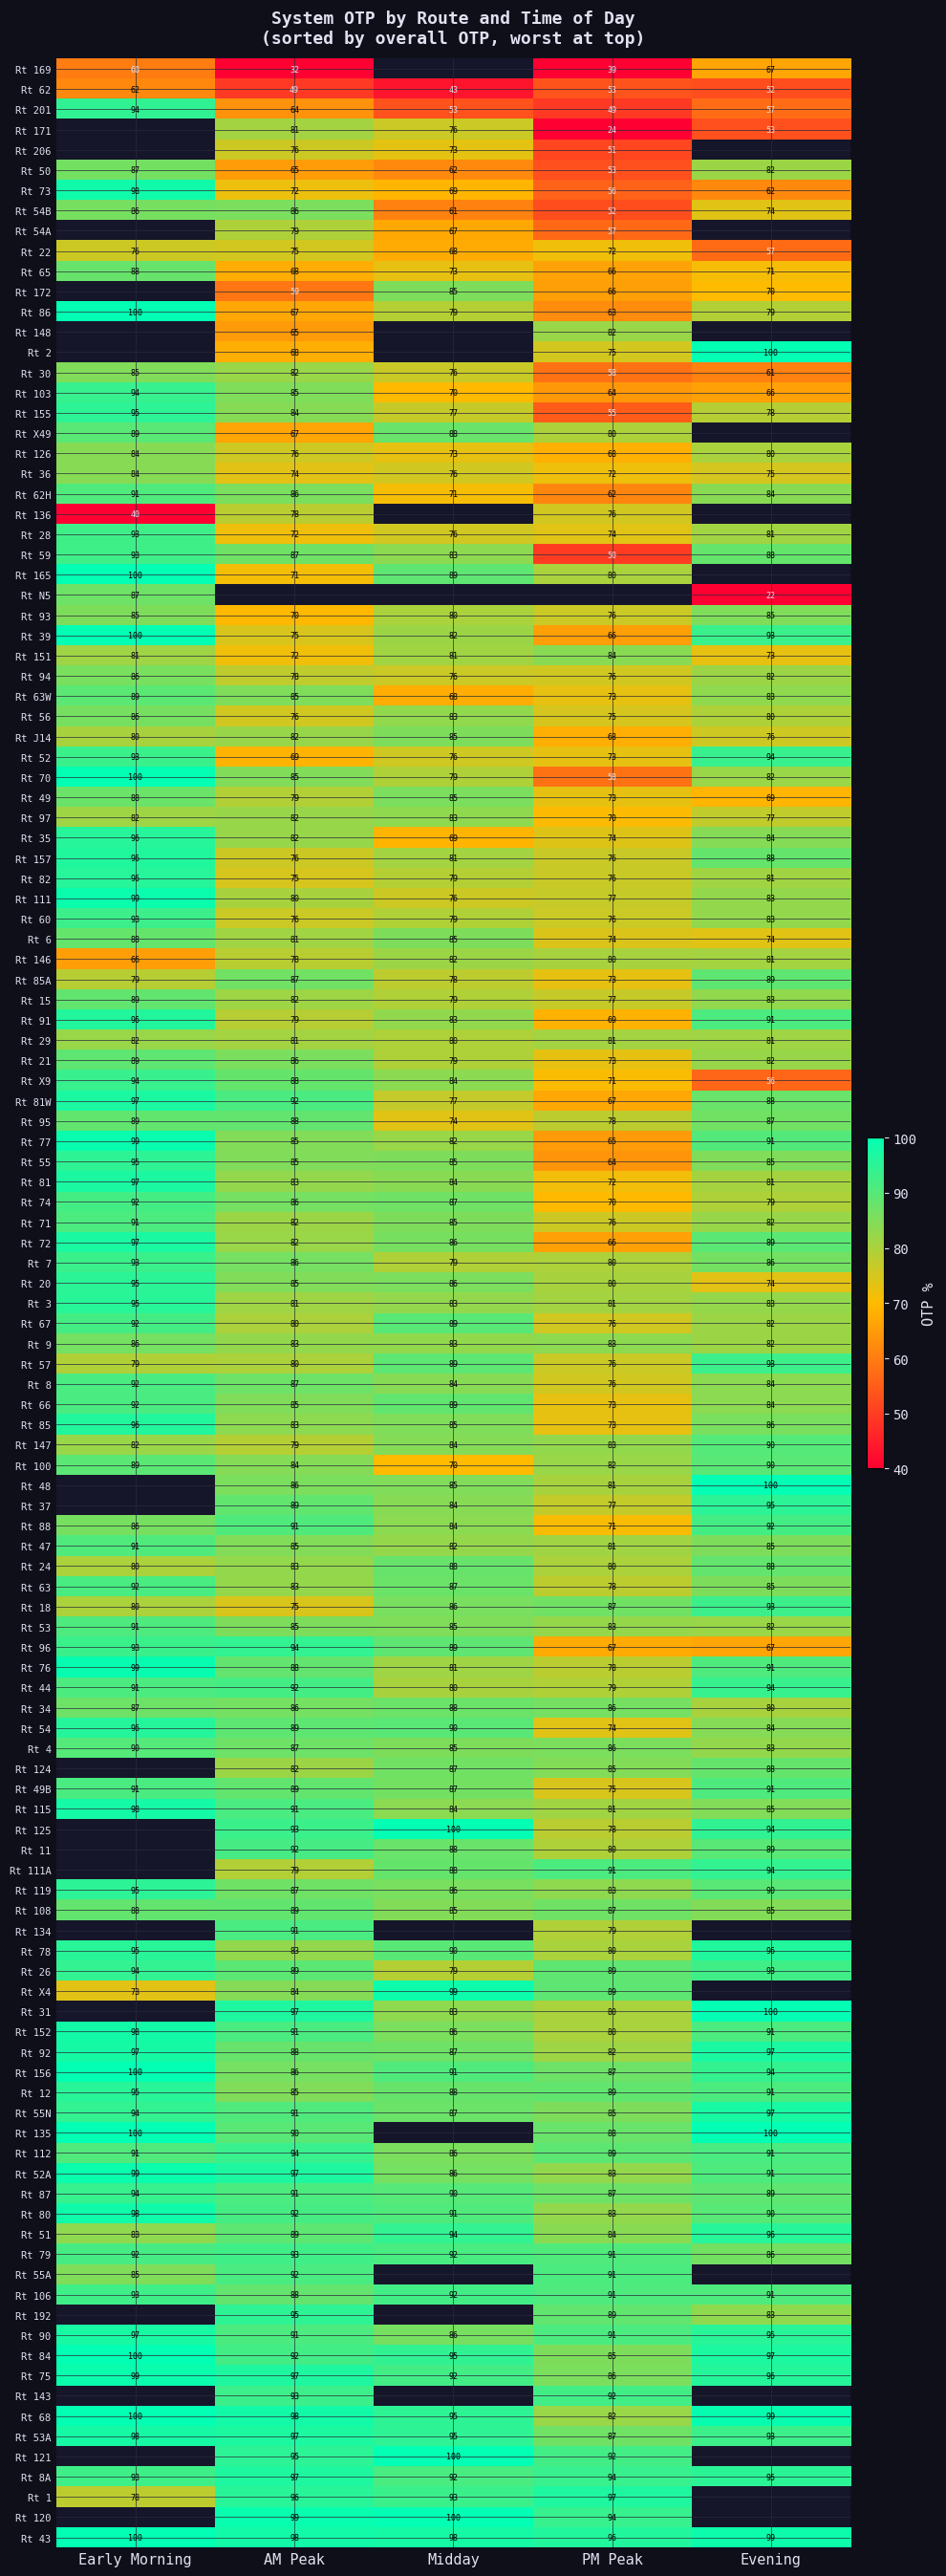

✓ OTP heatmap saved


In [37]:
# =============================================================================
# FIGURE — OTP Heatmap: Route × Time of Day
# Rows = routes sorted by overall OTP (worst at top)
# Columns = TOD buckets
# Color = OTP %
# =============================================================================

import matplotlib.colors as mcolors

tod_otp_cols = {
    'Early Morning': 'early_morning_otp_pct',
    'AM Peak':       'am_peak_otp_pct',
    'Midday':        'midday_otp_pct',
    'PM Peak':       'pm_peak_otp_pct',
    'Evening':       'evening_otp_pct',
}

heatmap_df = (
    perf.set_index('route_id')[list(tod_otp_cols.values())]
    .rename(columns={v: k for k, v in tod_otp_cols.items()})
)

# Sort worst routes to top
route_order = perf.sort_values('overall_otp_pct')['route_id'].values
heatmap_df  = heatmap_df.loc[route_order]

# Custom colormap: RED → YELLOW → GREEN
cmap = mcolors.LinearSegmentedColormap.from_list(
    'otp', [RED, YELLOW, GREEN], N=256
)

fig, ax = plt.subplots(figsize=(10, max(14, len(route_order)*0.22)), facecolor=BG)

im = ax.imshow(heatmap_df.values, aspect='auto', cmap=cmap, vmin=40, vmax=100)

# Axis labels
ax.set_xticks(range(len(tod_otp_cols)))
ax.set_xticklabels(list(tod_otp_cols.keys()), fontsize=11, color=WHITE)
ax.set_yticks(range(len(route_order)))
ax.set_yticklabels([f'Rt {r}' for r in route_order], fontsize=7.5, color=WHITE)
ax.tick_params(axis='both', which='both', length=0)

# Cell annotations for routes with extreme values
for i, route in enumerate(route_order):
    for j, tod in enumerate(tod_otp_cols.keys()):
        val = heatmap_df.loc[route, tod]
        if pd.notna(val):
            txt_color = 'black' if val > 60 else WHITE
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=6, color=txt_color)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('OTP %', color=WHITE, fontsize=11)
cbar.ax.yaxis.set_tick_params(color=WHITE, labelsize=10)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=WHITE)

ax.set_title('System OTP by Route and Time of Day\n(sorted by overall OTP, worst at top)',
             color=WHITE, fontsize=13, fontweight='bold', pad=12)
ax.set_facecolor(PANEL)
fig.patch.set_facecolor(BG)

plt.tight_layout()
plt.savefig('report_5_otp_heatmap.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 OTP heatmap saved')